In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("../data/Charlotin-hallucination_cases.csv")

In [6]:
df.head()

,Case Name,Court,State(s),Date,Party(ies),AI Tool,Hallucination,Outcome,Monetary Penalty,Professional Sanction,Key Principle,Pointer,Source,Details
0,The People v. Raziel Ruiz Alvarez,CA California,USA,2025-10-02,Lawyer,Unidentified,"Fabricated citation(s), false quotation, and m...",Published order; monetary sanction payable by ...,1500 USD,Yes,NaN,Volokh,https://reason.com/volokh/2025/10/04/court-esp...,"""When criminal defense attorneys fail to compl..."
1,In the Interest of R.A.,CA Iowa,USA,2025-10-01,Lawyer,Unidentified,Fabricated case/statute citations and inaccura...,Brief struck; Monetary penalty OR two hours of...,150 USD,Yes,NaN,NaN,/documents/834/In_the_Int._of_R.A.__2025_Iowa_...,NaN
2,In re the Marriage of D.X. and S.P.,CA California,USA,2025-09-30,Pro Se Litigant,Implied,fabricated citations (case law),Warning,NaN,No,NaN,NaN,/documents/838/In_re_the_Marriage_of_DX_and_SP...,The appellate opinion and editor's note identi...
3,Khoury et al v. Intermountain Health Care Inc....,D. Utah,USA,2025-09-30,Expert,ChatGPT,Fake evidence,Case dismissed,NaN,No,NaN,NaN,/documents/843/Khoury_et_al_v_Intermountain_He...,"Case dismissed for ""good cause"" in light of mo..."
4,Tomlin v. State of New Mexico,D. New Mexico,USA,2025-09-30,Pro Se Litigant,Implied,Fabricated citations to case law (AI-generated...,Warning,NaN,No,NaN,NaN,/documents/839/Tomlin_v._State_of_New_Mexico_U...,NaN


In [7]:
print("Nombre de lignes et colonnes :")
print(df.shape)

Nombre de lignes et colonnes :
(426, 14)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case Name              426 non-null    object
 1   Court                  414 non-null    object
 2   State(s)               423 non-null    object
 3   Date                   426 non-null    object
 4   Party(ies)             422 non-null    object
 5   AI Tool                417 non-null    object
 6   Hallucination          425 non-null    object
 7   Outcome                407 non-null    object
 8   Monetary Penalty       91 non-null     object
 9   Professional Sanction  426 non-null    object
 10  Key Principle          58 non-null     object
 11  Pointer                68 non-null     object
 12  Source                 395 non-null    object
 13  Details                253 non-null    object
dtypes: object(14)
memory usage: 46.7+ KB


In [9]:
df.columns

Index(['Case Name', 'Court', 'State(s)', 'Date', 'Party(ies)', 'AI Tool',
       'Hallucination', 'Outcome', 'Monetary Penalty', 'Professional Sanction',
       'Key Principle', 'Pointer', 'Source', 'Details'],
      dtype='object')

In [10]:
df.isnull().sum()

Case Name                  0
Court                     12
State(s)                   3
Date                       0
Party(ies)                 4
AI Tool                    9
Hallucination              1
Outcome                   19
Monetary Penalty         335
Professional Sanction      0
Key Principle            368
Pointer                  358
Source                    31
Details                  173
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

Case Name                 0.000000
Court                     2.816901
State(s)                  0.704225
Date                      0.000000
Party(ies)                0.938967
AI Tool                   2.112676
Hallucination             0.234742
Outcome                   4.460094
Monetary Penalty         78.638498
Professional Sanction     0.000000
Key Principle            86.384977
Pointer                  84.037559
Source                    7.276995
Details                  40.610329
dtype: float64

In [12]:
df.dropna(how="all", inplace=True)

In [13]:
df.shape

(426, 14)

In [14]:
df["AI Tool"].value_counts().head(10)

AI Tool
Implied         200
Unidentified    121
ChatGPT          45
implied           6
Copilot           3
Claude            2
MS Copilot        2
Unknown           1
GPT-4o            1
MobiOffice        1
Name: count, dtype: int64

In [15]:
import seaborn as sns

sns.set_style("whitegrid")

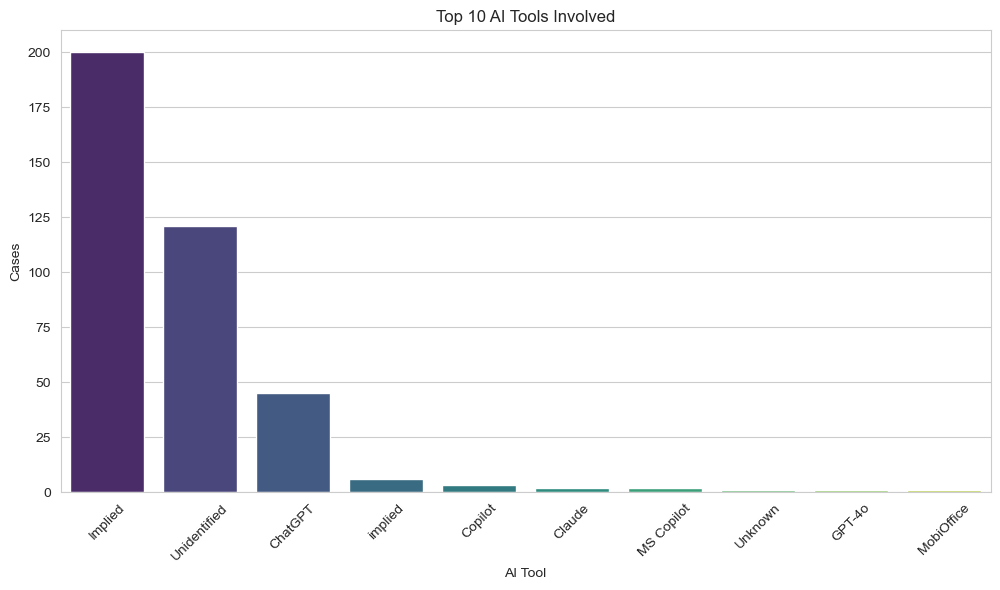

In [16]:
plt.figure(figsize=(12,6))

top_tools = df["AI Tool"].value_counts().head(10)

sns.barplot(
    x=top_tools.index,
    y=top_tools.values,
    hue=top_tools.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 AI Tools Involved")
plt.xlabel("AI Tool")
plt.ylabel("Cases")

plt.xticks(rotation=45)

plt.show()

In [17]:
df["Party(ies)"].value_counts()

Party(ies)
Pro Se Litigant            228
Lawyer                     179
Expert                       5
Judge                        3
Lawyer; Paralegal            2
Judge; Lawyer                1
Pro Se Litigant; Lawyer      1
Paralegal                    1
Prosecutor                   1
Federal Defender             1
Name: count, dtype: int64

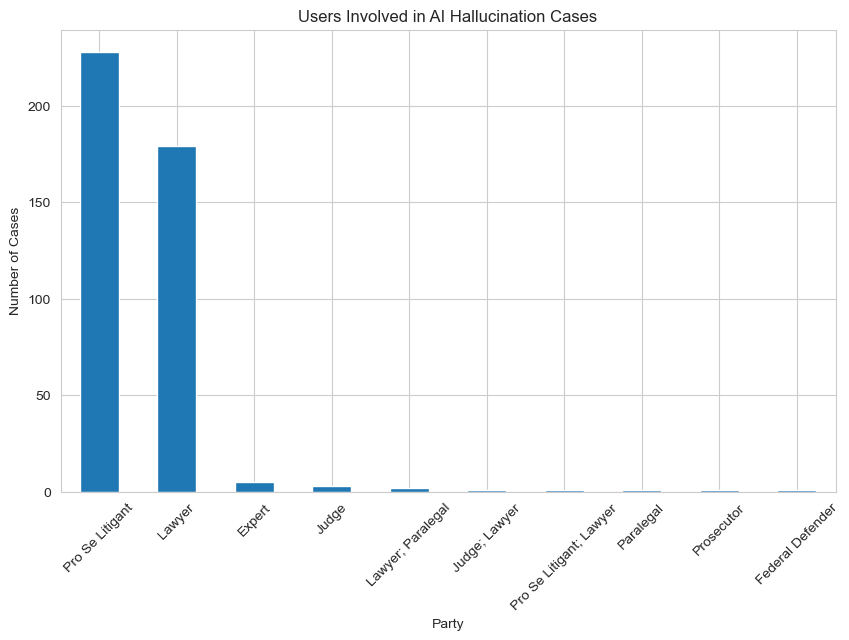

In [18]:
party_counts = df["Party(ies)"].value_counts()

plt.figure(figsize=(10,6))

party_counts.plot(kind="bar")

plt.title("Users Involved in AI Hallucination Cases")
plt.xlabel("Party")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.show()

In [19]:
df["Outcome"] = df["Outcome"].str.strip()

In [20]:
df["Outcome"] = df["Outcome"].replace({
    "Monetary sanction":"Monetary Sanction",
    "Monetary Sanctions":"Monetary Sanction",
    "Show Cause Order":"Order to show cause"
})

In [21]:
df["Outcome"].value_counts().head(10)

Outcome
Warning                                 104
Order to show cause                      14
Monetary Sanction                        13
Application dismissed                     4
Arguments ignored                         4
Order to pay opposing counsel's fees      3
Argument ignored                          2
Case dismissed                            2
Order to Show Cause                       2
Litigant lost on merits                   2
Name: count, dtype: int64

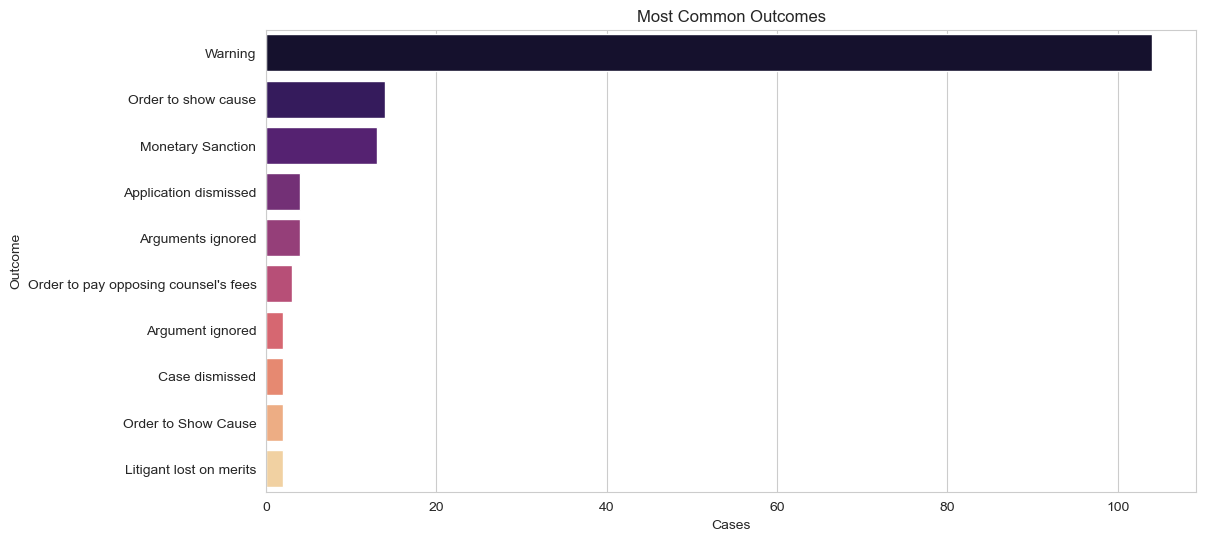

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_outcomes = df["Outcome"].value_counts().head(10)

# Fixed indentation - removed extra spaces before sns.barplot
sns.barplot(
    x=top_outcomes.values,
    y=top_outcomes.index,
    hue=top_outcomes.index,
    palette="magma",
    legend=False
)

plt.title("Most Common Outcomes")
plt.xlabel("Cases")
plt.ylabel("Outcome")

plt.show()

In [23]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)
df["Year"] = df["Date"].dt.year.astype("Int64")

In [24]:
print(df["Year"].dtype)

Int64


In [25]:
sorted(df["Year"].unique())

[np.int64(2023), np.int64(2024), np.int64(2025)]

In [26]:
#df["Year"].value_counts().sort_index()

In [27]:
#df[["Date","Year"]].head()

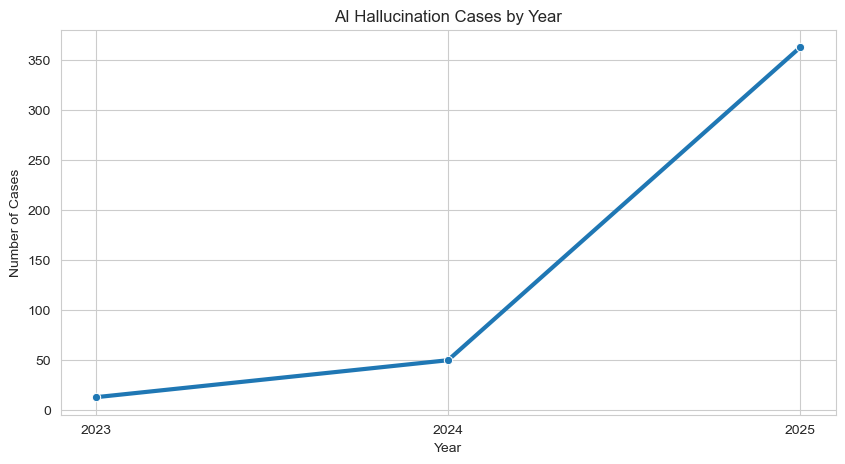

In [28]:
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker="o",
    linewidth=3
)

plt.title("AI Hallucination Cases by Year")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.xticks(year_counts.index)

plt.show()

In [29]:
from wordcloud import WordCloud

In [30]:
text = " ".join(
    df["Hallucination"].astype(str)
)

In [31]:
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate(text)

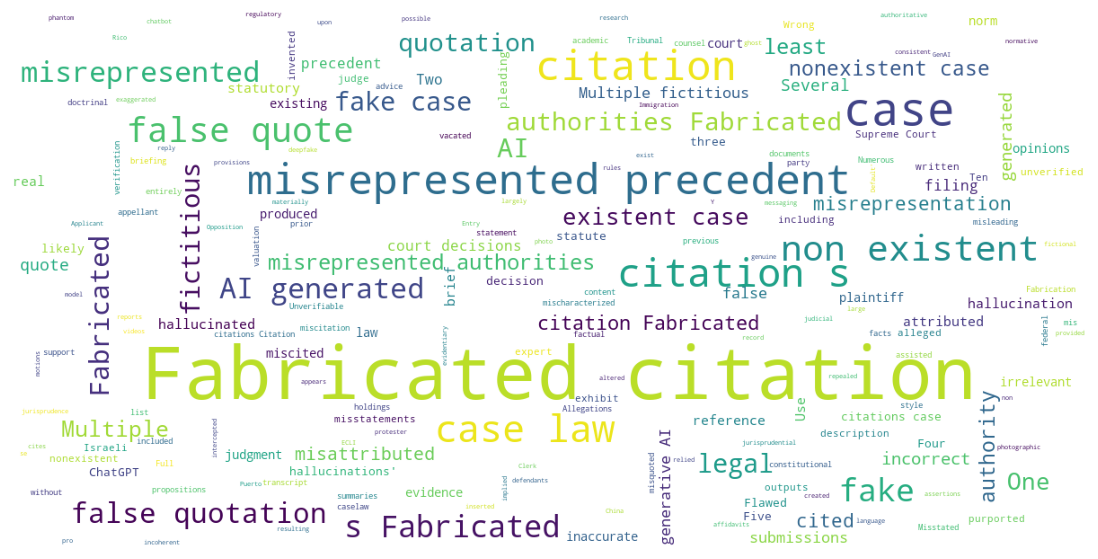

In [32]:
plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.show()

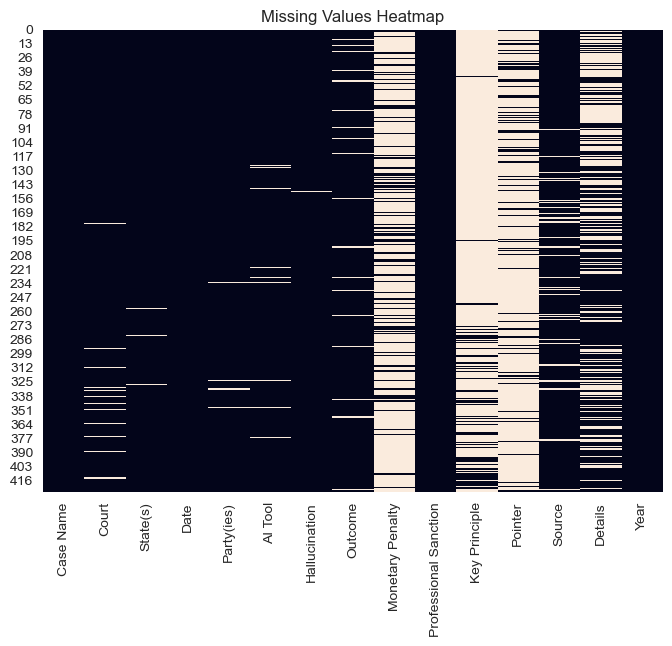

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [34]:
def severity(outcome):

    outcome = str(outcome).lower()

    high = [
        "monetary sanction",
        "case dismissed",
        "application dismissed",
        "order to pay opposing counsel's fees",
        "professional sanction"
    ]

    medium = [
        "show cause",
        "arguments ignored",
        "argument ignored"
    ]

    if any(word in outcome for word in high):
        return "High"

    elif any(word in outcome for word in medium):
        return "Medium"

    else:
        return "Low"

In [35]:
df["Severity"] = df["Outcome"].apply(severity)

In [36]:
df["Severity"].value_counts()

Severity
Low       324
High       67
Medium     35
Name: count, dtype: int64

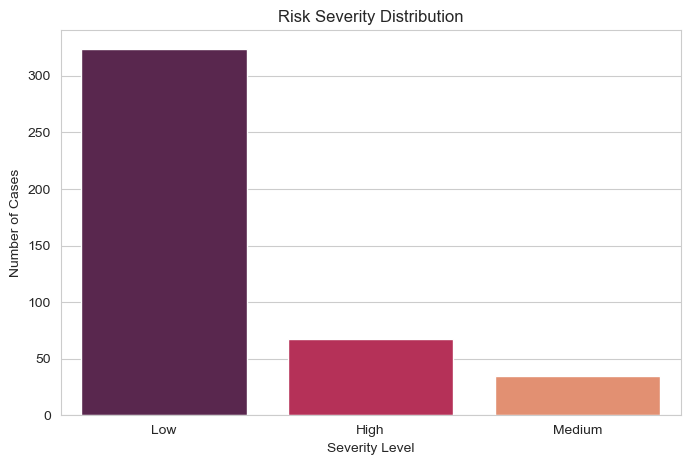

In [37]:
plt.figure(figsize=(8,5))

severity_counts = df["Severity"].value_counts()

sns.barplot(
    x=severity_counts.index,
    y=severity_counts.values,
    hue=severity_counts.index,
    palette="rocket",
    legend=False
)

plt.title("Risk Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Cases")

plt.show()

In [38]:
df["text"] = df["Hallucination"].astype(str) + " " + df["Details"].astype(str)

In [39]:
df["Severity"] = df["Outcome"].apply(severity)

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib

In [41]:
df["text"] = df["Hallucination"].astype(str) + " " + df["Details"].astype(str)

X = df["text"]
y = df["Severity"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [64]:
model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [65]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.41      0.50      0.45        14
         Low       0.85      0.78      0.82        65
      Medium       0.11      0.14      0.12         7

    accuracy                           0.69        86
   macro avg       0.46      0.48      0.46        86
weighted avg       0.72      0.69      0.70        86



In [73]:
joblib.dump(model, "hallucination_model.pkl")

['hallucination_model.pkl']

In [77]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load model
model = joblib.load("Hallucination_model.pkl")

# Load data
df = pd.read_csv("data/Charlotin-hallucination_cases.csv")

# =========================
# SIDEBAR
# =========================
st.sidebar.image("images/logo_university.png", width=150)

st.sidebar.title("AI Project")
st.sidebar.write("Ikram Khaddoum")
st.sidebar.write("Supervisor: Pr. Arroud")

# =========================
# TITLE
# =========================
st.title("AI Hallucination Risk Prediction System")

# =========================
# DATASET STATS
# =========================
st.header("Dataset Overview")

col1, col2, col3 = st.columns(3)

col1.metric("Total Cases", len(df))
col2.metric("AI Tools", df["AI Tool"].nunique())
col3.metric("Courts", df["Court"].nunique())

st.dataframe(df.head())

# =========================
# GRAPH 1
# =========================
st.header("AI Tools Distribution")

tool_counts = df["AI Tool"].value_counts().head(10)

fig, ax = plt.subplots()
ax.barh(tool_counts.index, tool_counts.values)
st.pyplot(fig)

# =========================
# PREDICTION
# =========================
st.header("Risk Prediction")

text = st.text_area("Enter hallucination text")

if st.button("Predict"):

    prediction = model.predict([text])[0]

    if prediction == "High":
        st.error("🚨 High Risk")
    elif prediction == "Medium":
        st.warning("⚠️ Medium Risk")
    else:
        st.success("✅ Low Risk")

Overwriting app.py


In [66]:
prediction = model.predict(["The AI generated a fake legal citation"])
print(prediction)

['High']


In [67]:
print(y_test.value_counts())

Severity
Low       65
High      14
Medium     7
Name: count, dtype: int64


In [68]:
import pandas as pd

print(pd.Series(y_pred).value_counts())

Low       60
High      17
Medium     9
Name: count, dtype: int64


In [69]:
print(df["Severity"].value_counts())

Severity
Low       324
High       67
Medium     35
Name: count, dtype: int64


In [70]:
print(model)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])
